# Task 4: Loan Default Prediction using Lending Club Data

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset 

In [2]:
df = pd.read_csv('accepted_2007_to_2018Q4.csv', low_memory=False, nrows=20000)

# Select Relevant Features

In [3]:
selected_columns = ['loan_amnt', 'term', 'int_rate', 'emp_length', 'home_ownership',
                    'annual_inc', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_high',
                    'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'loan_status']

df = df[selected_columns]

# Convert target to binary (Fully Paid = 0, Charged Off = 1)

In [4]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

# Handle Missing Values

In [5]:
df.dropna(inplace=True)

# Encode Categorical Features

In [7]:
for col in ['term', 'emp_length', 'home_ownership', 'purpose']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Define Features and Target

In [8]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Handle Class Imbalance

In [9]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Train Model

In [11]:
model = GradientBoostingClassifier()
model.fit(X_train, y_train)

GradientBoostingClassifier()

# Evaluate

In [13]:
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.83      2667
           1       0.84      0.83      0.83      2651

    accuracy                           0.83      5318
   macro avg       0.83      0.83      0.83      5318
weighted avg       0.83      0.83      0.83      5318

Confusion Matrix:
 [[2238  429]
 [ 462 2189]]


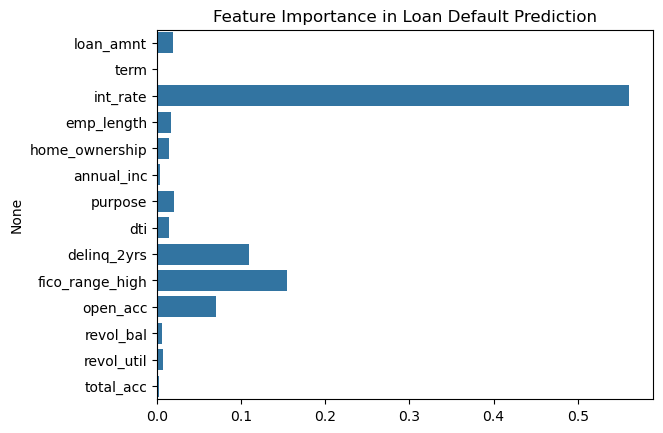

In [14]:
importances = model.feature_importances_
features = X.columns
sns.barplot(x=importances, y=features)
plt.title("Feature Importance in Loan Default Prediction")
plt.show()